## **Extract V1 L2/3 responses to natural scenes from Allen Visual Coding Neuropixels dataset**
Author: patrick.mccarthy@dpag.ox.ac.uk

In [59]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from allensdk.core.reference_space_cache import ReferenceSpaceCache

Load data

In [4]:
# initialise cache
CACHE_DIR = Path('/Users/pmccarthy/Documents/experimental_data/allen_visual_neuropixels') 
CACHE_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = CACHE_DIR / 'manifest.json'
cache = EcephysProjectCache.from_warehouse(manifest=str(manifest_path))

In [ ]:
# load session table
sessions = cache.get_session_table()

In [11]:
# identify sessions which contain natural scene stimuli and V1 neurons
has_visp = ['VISp' in str(areas) for areas in sessions.ecephys_structure_acronyms] # boolean indicating presence of VISp in area list
# get relevant sessions 
v1_ns_sessions = sessions[
    (sessions.session_type == 'brain_observatory_1.1') & # "brain_observatory_1.1" sessions contain natural scene stimuli
    has_visp
] 

print(f'{len(v1_ns_sessions)} sessions with VISp + natural scenes')

v1_ns_sessions[['sex', 'full_genotype', 'session_type', 'ecephys_structure_acronyms']].head(10)

32 sessions with VISp + natural scenes


,sex,full_genotype,session_type,ecephys_structure_acronyms
id,,,,
715093703,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,brain_observatory_1.1,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,brain_observatory_1.1,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,brain_observatory_1.1,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,M,wt/wt,brain_observatory_1.1,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,M,wt/wt,brain_observatory_1.1,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"
739448407,M,wt/wt,brain_observatory_1.1,"[grey, VISam, nan, VIS, VISp, VISl, VISrl]"
742951821,M,wt/wt,brain_observatory_1.1,"[VISal, nan, grey, VISl, VISrl, VISp, VISpm, VIS]"
743475441,M,wt/wt,brain_observatory_1.1,"[LP, LGd, HPF, DG, CA3, CA1, VISrl, nan, PP, P..."
744228101,M,wt/wt,brain_observatory_1.1,"[Eth, TH, LP, POL, APN, DG, CA1, VIS, nan, CA3..."


In [13]:
# download first session (if not already downloaded) and load data
session_id = v1_ns_sessions.index[0]
session = cache.get_session_data(session_id)

/Users/pmccarthy/.local/share/mamba/envs/designer_waveform/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/Users/pmccarthy/.local/share/mamba/envs/designer_waveform/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Get natural scene trial IDs and get stimulus images for reference

In [ ]:
# get indices of trials with natural scene stimuli
ns_table = session.get_stimulus_table('natural_scenes')
ns_valid = ns_table[ns_table.frame >= 0].copy()  # exclude blank (frame == -1)
frame_ids = ns_valid.frame.values.astype(int)

In [62]:
# # get stimuli and save locally
# ns_images = np.stack([cache.get_natural_scene_template(id) for id in range(118)])
# # save as pickle with frame IDs as index
# with open(CACHE_DIR / f'{session_id}_natural_scene_images.pkl', 'wb') as f:
#     pickle.dump((frame_ids, ns_images), f)

Find V1 L2/3 units

In [38]:
# download CCF annotation volume for retrieving structure IDs from unit coordinates
resolution = 10  # resolution in microns per voxel
rsc = ReferenceSpaceCache(
    resolution=resolution,
    reference_space_key='annotation/ccf_2017',
    manifest=str(CACHE_DIR / 'reference_space_manifest.json')
)
annot, _ = rsc.get_annotation_volume()  # shape (1320, 800, 1140), uint32 (annotation volume)
structure_tree = rsc.get_structure_tree() # structure tree with metadata for each structure ID (including acronym, name, parent structure, etc.)
id_to_acronym = {s['id']: s['acronym'] for s in structure_tree.nodes()}  # mapping from structure ID to structure acronym (e.g. 385 -> 'VISp')

In [17]:
# filter for V1 units
v1_units = session.units[session.units.ecephys_structure_acronym == 'VISp'].copy()

In [ ]:
# get CCF coordinates of V1 units
coords = v1_units[['anterior_posterior_ccf_coordinate',
                      'dorsal_ventral_ccf_coordinate',
                      'left_right_ccf_coordinate']].values
voxels = (coords / resolution).astype(int)  # convert to voxel indices
structure_ids = annot[voxels[:, 0], voxels[:, 1], voxels[:, 2]] # get structure IDs for each unit based on coordinates
v1_units['layer'] = [id_to_acronym.get(sid, 'unknown') for sid in structure_ids]

# print summary statistics of unit vertical positions by layer
print(v1_units.groupby('layer')['probe_vertical_position'].describe())


         count         mean        std     min     25%     50%     75%     max
layer                                                                         
VISp2/3    5.0  3192.000000  65.726707  3120.0  3160.0  3160.0  3240.0  3280.0
VISp4     13.0  2949.230769  37.960844  2900.0  2920.0  2940.0  2980.0  3020.0
VISp5     26.0  2798.461538  59.845956  2700.0  2740.0  2790.0  2855.0  2880.0
VISp6a    16.0  2625.000000  29.664794  2580.0  2600.0  2630.0  2640.0  2680.0


In [36]:
# isolate units in L2/3
l23_units = v1_units[v1_units.layer.isin(['VISp2/3', 'VISp2/3a', 'VISp2/3b'])]
print(f'{len(l23_units)} units in L2/3')

5 units in L2/3


Get responses for chosen units and trials

In [63]:
ns_valid

,stimulus_block,start_time,stop_time,frame,stimulus_name,duration,stimulus_condition_id
stimulus_presentation_id,,,,,,,
51353,9.0,5892.415053,5892.665249,5.0,natural_scenes,0.250196,4908
51354,9.0,5892.665249,5892.915445,114.0,natural_scenes,0.250196,4909
51355,9.0,5892.915445,5893.165641,13.0,natural_scenes,0.250196,4910
51356,9.0,5893.165641,5893.415837,70.0,natural_scenes,0.250196,4911
51357,9.0,5893.415837,5893.666049,26.0,natural_scenes,0.250211,4912
...,...,...,...,...,...,...,...
68222,13.0,8550.902302,8551.152520,24.0,natural_scenes,0.250219,5006
68223,13.0,8551.152520,8551.402739,107.0,natural_scenes,0.250219,4969
68224,13.0,8551.402739,8551.652957,100.0,natural_scenes,0.250219,4924


In [78]:
# count occurrences of each frame ID
frame_counts = ns_valid.frame.astype(int).value_counts().sort_index()

In [109]:
# define parameters for PSTH computation
BIN_SIZE = 0.01   # 10 ms
T_PRE    = 0.0 
T_POST   = 0.25  

bin_edges = np.arange(-T_PRE, T_POST + BIN_SIZE, BIN_SIZE)

In [110]:
# initialise response array: (num_stim, num_trials, num_bins, num_units)
# num_trials = min across stimuli so every stimulus has equal-length trials
num_stim   = len(frame_counts)
num_trials = int(frame_counts.min())
num_units  = len(l23_units)
num_bins   = len(bin_edges) - 1
responses  = np.zeros((num_stim, num_trials, num_bins, num_units))

In [111]:
# collect responses into matrix
unit_ids = l23_units.index.values
for i, frame_id in enumerate(frame_counts.index):
    trial_ids = ns_valid[ns_valid.frame == frame_id].index.values[:num_trials]
    responses[i, :, :, :] = session.presentationwise_spike_counts(
        stimulus_presentation_ids=trial_ids,
        bin_edges=bin_edges,
        unit_ids=unit_ids,
    ).values  # (num_trials, num_bins, num_units)

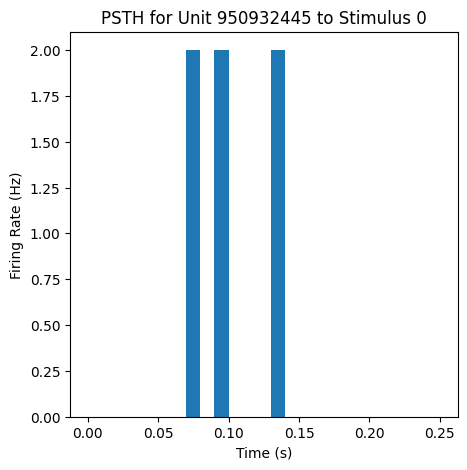

In [112]:
# plot an example PSTH as a sanity check
stim_idx = 0  # index of stimulus to plot
unit_idx = 0  # index of unit to plot
psth = responses[stim_idx, :, :, unit_idx].mean(axis=0) / BIN_SIZE  # average across trials and convert to firing rate

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.bar(bin_edges[:-1], psth, width=BIN_SIZE, align='edge')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title(f'PSTH for Unit {unit_ids[unit_idx]} to Stimulus {frame_counts.index[stim_idx]}')
plt.show()

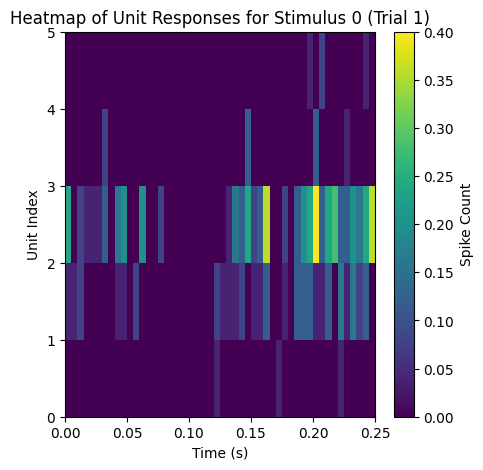

In [113]:
# plot trial-averaged heatmap of all units for example stim
trial_idx = 1  # index of trial to plot
heatmap = np.mean(responses[stim_idx, :, :, :], axis=1).T  # shape (num_units, num_bins)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im = ax.imshow(heatmap, aspect='auto', origin='lower', extent=[bin_edges[0], bin_edges[-1], 0, num_units])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Unit Index')
ax.set_title(f'Heatmap of Unit Responses for Stimulus {frame_counts.index[stim_idx]} (Trial {trial_idx})')
fig.colorbar(im, ax=ax, label='Spike Count')
plt.show()

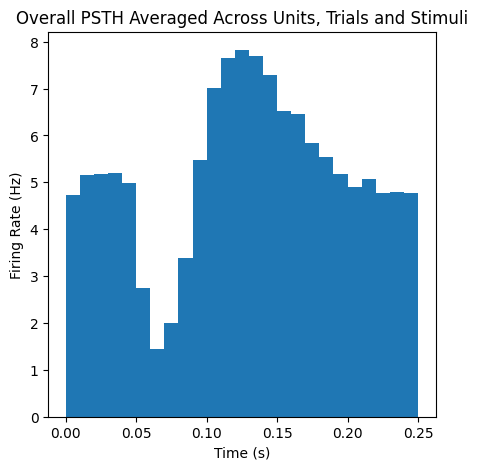

In [114]:
# average all units, trials and stimuli together to get overall PSTH
overall_psth = responses.mean(axis=(0, 1, 3)) / BIN_SIZE  # shape (num_bins,)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.bar(bin_edges[:-1], overall_psth, width=BIN_SIZE, align='edge')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title('Overall PSTH Averaged Across Units, Trials and Stimuli')
plt.show()

Save data in local path

In [94]:
print(f'responses shape (stim × trials × bins × units): {responses.shape}')

(118, 50, 25, 5)

In [ ]:
# session_id already set above

In [ ]:
# save response matrix as pickle with frame IDs and unit IDs as indices
response_data = {
    'frame_ids': frame_counts.index.values,
    'unit_ids': unit_ids,
    'bin_edges': bin_edges,
    'responses': responses
}
with open(CACHE_DIR / f'{session_id}_l23_psth_responses.pkl', 'wb') as f:
    pickle.dump((frame_counts.index.values, unit_ids, bin_edges, responses), f)